## COVID Drivers: Modeling

### Table of Contents
* [Read the Data](#read)</BR>
* [Time Series Decomposition](#decomp)</BR>
* [Changes in Seasonal Behavior Over Time](#season-x)</BR>



Import packages

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os
import altair as alt

import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_final.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [ ]:
df_init = pd.read_csv(path_in, low_memory=False)

In [ ]:
df_init.head()

,CRN,CRASH_DATE,URBAN_RURAL,URBAN_RURALx,POST_COVID,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,CELL_PHONE,DISTRACTED
0,2005000003,2005-01-01,1,Rural,0,1,0,0,0,0,0,1,0,0,0
1,2005000006,2005-01-01,1,Rural,0,1,0,0,0,0,0,1,0,0,0
2,2005000010,2005-01-01,2,Urbanized,0,1,0,0,0,0,1,1,0,0,0
3,2005000012,2005-01-01,2,Urbanized,0,1,0,1,0,0,0,0,0,0,0
4,2005000013,2005-01-01,1,Rural,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460484 entries, 0 to 2460483
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   CRN                 int64 
 1   CRASH_DATE          object
 2   URBAN_RURAL         int64 
 3   URBAN_RURALx        object
 4   POST_COVID          int64 
 5   AGGRESSIVE_DRIVING  int64 
 6   NHTSA_AGG_DRIVING   int64 
 7   NO_CLEARANCE        int64 
 8   RUNNING_RED_LT      int64 
 9   RUNNING_STOP_SIGN   int64 
 10  SPEEDING            int64 
 11  SPEEDING_RELATED    int64 
 12  TAILGATING          int64 
 13  CELL_PHONE          int64 
 14  DISTRACTED          int64 
dtypes: int64(13), object(2)
memory usage: 281.6+ MB


In [ ]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [ ]:
summ_idx = df_init.drop(columns=['URBAN_RURAL', 'URBAN_RURALx']).copy().set_index('CRASH_DATE')

In [ ]:
summ_idx.head()

,CRN,POST_COVID,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,CELL_PHONE,DISTRACTED
CRASH_DATE,,,,,,,,,,,,
2005-01-01,2005000003,0,1,0,0,0,0,0,1,0,0,0
2005-01-01,2005000006,0,1,0,0,0,0,0,1,0,0,0
2005-01-01,2005000010,0,1,0,0,0,0,1,1,0,0,0
2005-01-01,2005000012,0,1,0,1,0,0,0,0,0,0,0
2005-01-01,2005000013,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
summ_by_date = summ_idx.copy().resample('MS').mean()

In [ ]:
all_flags = ['AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'CELL_PHONE',
 'DISTRACTED']

In [ ]:
some_flags = ['NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'CELL_PHONE']

### <a id='decomp'>Time Series Decomposition</a>

In [ ]:
for c in all_flags:
    ready_series = summ_by_date.loc[:,c].copy()

    my_decomposition = sm.tsa.seasonal_decompose(ready_series, model='additive')

    plt.rcParams['figure.figsize'] = 18,8
    plt.show()

    print(c.replace('_',' ').title())

    fig = my_decomposition.plot()
    #fig.savefig('images/decompoistion_' + c)

    df_decomp = pd.DataFrame({'observed': my_decomposition.observed,
                          'seasonal_adjusted': my_decomposition.observed - my_decomposition.seasonal},
                        index=ready_series.index)

    fig = sns.relplot( data = df_decomp, kind='line', aspect=2.5 )
    plt.show()
    #fig.savefig('images/seasonal_adjusted_' + c)

    fig, ax = plt.subplots(figsize=(12, 8))
    fig = sm.graphics.tsa.month_plot( ready_series, ylabel=c.replace('_',' ').title(), ax=ax )
    plt.show()
    #fig.savefig('images/monthly_variation_' + c)

    fig, ax = plt.subplots(figsize=(12, 8))
    fig = sm.graphics.tsa.month_plot( my_decomposition.seasonal, ylabel=c.replace('_',' ').title(), ax=ax )
    plt.show()
    #fig.savefig('images/seasonal_pattern_' + c)

Output hidden; open in https://colab.research.google.com to view.

### <a id='season-x'>Changes in Seasonal Behavior Over Time</a>

In [ ]:
ready_series.shape

(240,)


Aggressive Driving


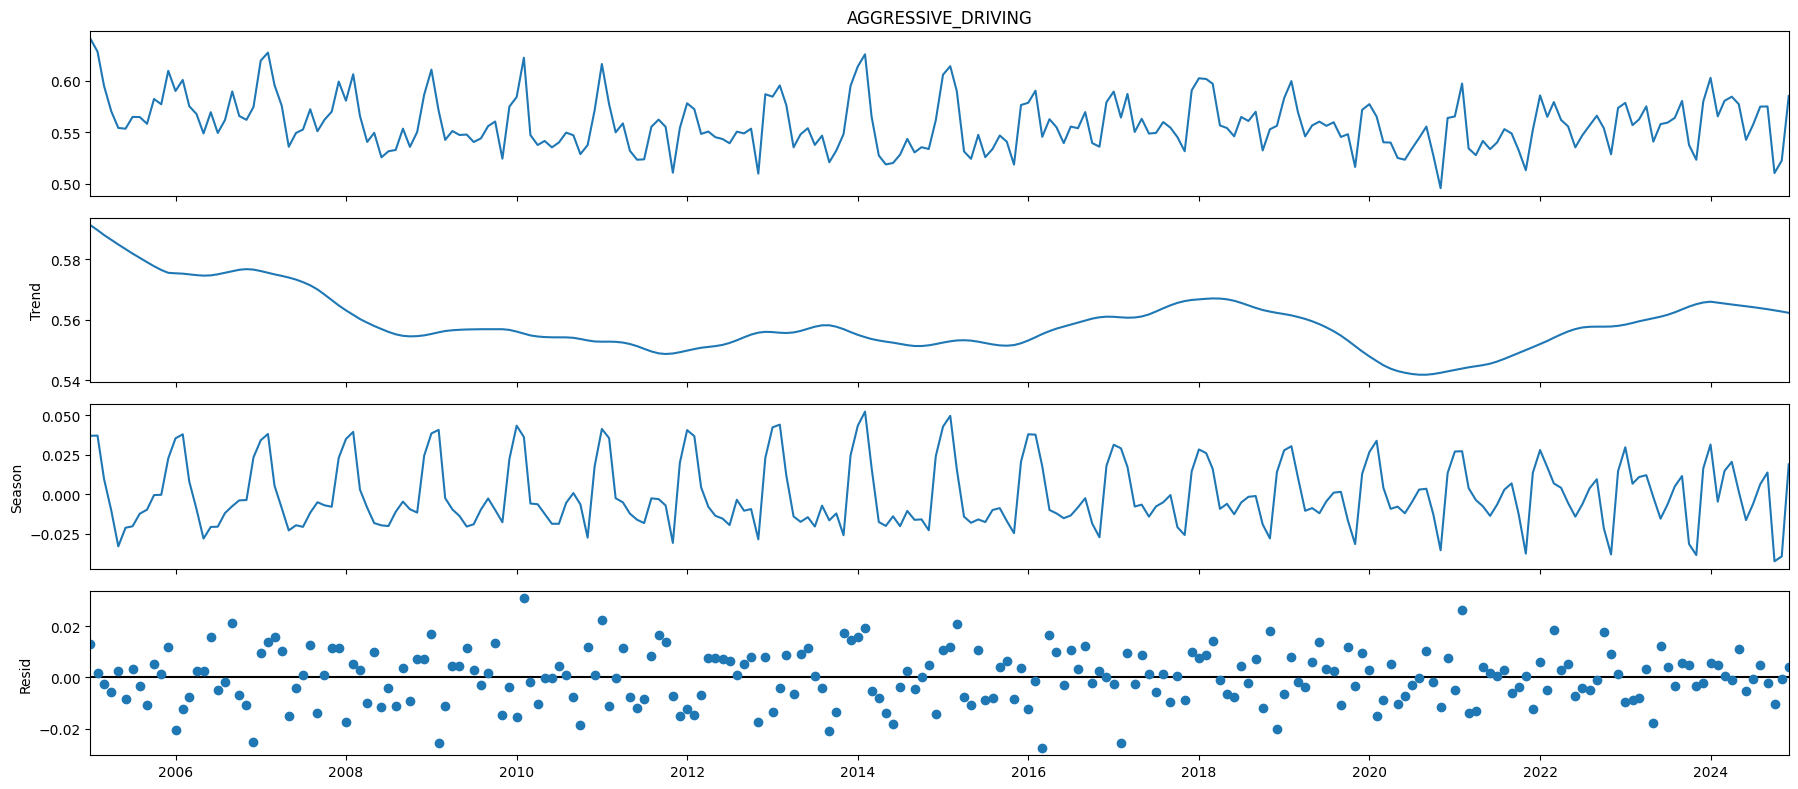

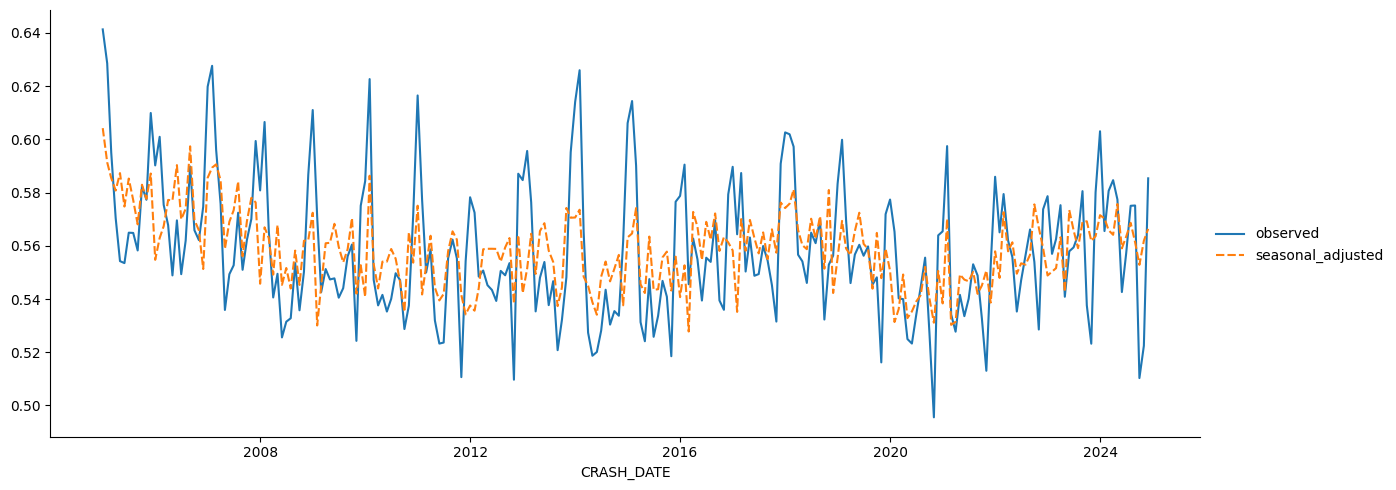

In [ ]:
ready_series = summ_by_date.loc[:,'AGGRESSIVE_DRIVING'].copy()
ready_stl = STL( ready_series )
ready_stl_fit = ready_stl.fit()
fig = ready_stl_fit.plot()
print()
print('Aggressive Driving')
plt.show()

df_stl = pd.DataFrame({'observed': ready_stl_fit.observed,
            'seasonal_adjusted': ready_stl_fit.observed - ready_stl_fit.seasonal,
            'detrend': ready_stl_fit.observed - ready_stl_fit.trend},
                index=ready_series.index)

sns.relplot( data = df_stl.loc[:, ['observed', 'seasonal_adjusted']], kind='line', aspect=2.5 )
plt.show()

In [ ]:
ready_stl_fit.observed.shape[0]

240

In [ ]:
ready_stl_fit.seasonal

,season
CRASH_DATE,
2005-01-01,0.037090
2005-02-01,0.037195
2005-03-01,0.009640
2005-04-01,-0.010356
2005-05-01,-0.033070
...,...
2024-08-01,0.006386
2024-09-01,0.013793
2024-10-01,-0.042518


In [ ]:
ready_stl_fit.trend

,trend
CRASH_DATE,
2005-01-01,0.591189
2005-02-01,0.589529
2005-03-01,0.587913
2005-04-01,0.586335
2005-05-01,0.584792
...,...
2024-08-01,0.563804
2024-09-01,0.563454
2024-10-01,0.563077


In [ ]:
summ_by_date_post = summ_by_date.loc[summ_by_date['POST_COVID']==1].copy()

In [ ]:
summ_by_date_pre = summ_by_date.loc[summ_by_date['POST_COVID']==0].copy()

In [ ]:
for c in all_flags:
    ready_series = summ_by_date_pre.loc[:,c].copy()
    ready_stl = STL( ready_series )
    ready_stl_fit = ready_stl.fit()
    fig = ready_stl_fit.plot()
    print()
    print(c.replace('_',' ').title())
    plt.show()

    df_stl = pd.DataFrame({'observed': ready_stl_fit.observed,
            'seasonal_adjusted': ready_stl_fit.observed - ready_stl_fit.seasonal,
            'detrend': ready_stl_fit.observed - ready_stl_fit.trend},
                index=ready_series.index)

    sns.relplot( data = df_stl.loc[:, ['observed', 'seasonal_adjusted']], kind='line', aspect=2.5 )
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 8))
    fig = sm.graphics.tsa.month_plot( df_stl.detrend, ylabel=c.replace('_',' ').title(), ax=ax )
    plt.show()

    # Detrended data can be further smoothed by removing the residual
    df_stl['detrend_smooth'] = ready_stl_fit.observed - (ready_stl_fit.trend + ready_stl_fit.resid)

    fig, ax = plt.subplots(figsize=(12, 8))
    fig = sm.graphics.tsa.month_plot( df_stl.detrend_smooth, ylabel=c.replace('_',' ').title(), ax=ax )
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for c in all_flags:
    ready_series = summ_by_date_post.loc[:,c].copy()
    ready_stl = STL( ready_series )
    ready_stl_fit = ready_stl.fit()
    fig = ready_stl_fit.plot()
    print()
    print(c.replace('_',' ').title())
    plt.show()

    df_stl = pd.DataFrame({'observed': ready_stl_fit.observed,
            'seasonal_adjusted': ready_stl_fit.observed - ready_stl_fit.seasonal,
            'detrend': ready_stl_fit.observed - ready_stl_fit.trend},
                index=ready_series.index)

    sns.relplot( data = df_stl.loc[:, ['observed', 'seasonal_adjusted']], kind='line', aspect=2.5 )
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 8))
    fig = sm.graphics.tsa.month_plot( df_stl.detrend, ylabel=c.replace('_',' ').title(), ax=ax )
    plt.show()

    # Detrended data can be further smoothed by removing the residual
    df_stl['detrend_smooth'] = ready_stl_fit.observed - (ready_stl_fit.trend + ready_stl_fit.resid)

    fig, ax = plt.subplots(figsize=(12, 8))
    fig = sm.graphics.tsa.month_plot( df_stl.detrend_smooth, ylabel=c.replace('_',' ').title(), ax=ax )
    plt.show()

Output hidden; open in https://colab.research.google.com to view.